# Trabajo Final: Predicción del salario anual (CRISP-DM)
**Integrantes:** Daniel Jaramillo Guillén y Miguel Ángel López Ríos

## 4. Modelamiento y evaluación

Este cuaderno continúa el punto 3 (Preparación de datos). Usa como entrada `Employee_Salaries_preparado.csv` (994 registros, 7 predictoras + `Salary` + `Salary_estrato`) y exporta todos los modelos entrenados en formato `.joblib`, que luego consume la aplicación de Streamlit (`app.py`).

| Sección | Contenido |
|---|---|
| 1.1 | Selección de 5 modelos clásicos y 3 ensambles (votación, bagging y boosting) |
| 1.2 | Ajuste de hiperparámetros con el 70 % de los datos y validación cruzada |
| 1.3 | Evaluación con el 30 % de prueba y selección del mejor modelo |

In [1]:
import os, time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import VotingRegressor, BaggingRegressor, GradientBoostingRegressor
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.3f}'.format)
sns.set_theme(style='whitegrid', palette='deep')
SEED = 42
os.makedirs('figuras', exist_ok=True)
os.makedirs('modelos', exist_ok=True)

### Carga de datos
En Google Colab, si el archivo no está en el entorno, se abre un cuadro para subirlo.

In [2]:
ARCHIVO = 'Employee_Salaries_preparado.csv'
if not os.path.exists(ARCHIVO):
    from google.colab import files
    files.upload()

df = pd.read_csv(ARCHIVO)
FEATURES = ['YearsExperience', 'JobLevel', 'Education', 'Remote',
            'CompanySize_Small', 'CompanySize_Medium', 'CompanySize_Large']
TARGET = 'Salary'
print(df.shape)
df.head()

(994, 9)


,YearsExperience,JobLevel,Education,Remote,CompanySize_Small,CompanySize_Medium,CompanySize_Large,Salary,Salary_estrato
0,0.000,5,1,1,0,0,1,"78,308.710",2
1,12.400,4,1,1,0,0,1,"92,835.250",3
2,6.700,2,1,0,0,0,1,"75,619.520",2
3,40.000,3,0,0,0,1,0,"119,105.300",4
4,0.000,4,3,0,1,0,0,"85,813.050",3


### Partición 70 / 30 estratificada
El 70 % se usa **solo** para entrenar y ajustar hiperparámetros (con validación cruzada). El 30 % queda guardado y **no se toca** hasta la evaluación final (1.3). La partición se estratifica con `Salary_estrato` (quintiles del salario, creados en el punto 3.8) para que entrenamiento y prueba tengan la misma proporción de salarios bajos, medios y altos.

In [3]:
X, y, estrato = df[FEATURES], df[TARGET], df['Salary_estrato']
X_train, X_test, y_train, y_test, est_train, est_test = train_test_split(
    X, y, estrato, test_size=0.30, random_state=SEED, stratify=estrato)
print(f'Entrenamiento: {X_train.shape[0]} registros | Prueba: {X_test.shape[0]} registros')
print(pd.DataFrame({'train': est_train.value_counts(normalize=True).sort_index(),
                    'test': est_test.value_counts(normalize=True).sort_index()}))

# Validación cruzada estratificada de 5 pliegues, solo sobre el 70 % de entrenamiento
cv = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(X_train, est_train))

Entrenamiento: 695 registros | Prueba: 299 registros
                train  test
Salary_estrato             
0               0.200 0.201
1               0.200 0.201
2               0.200 0.197
3               0.200 0.201
4               0.200 0.201


## 1.1 Configuración y selección de métodos de Machine Learning

El problema es de **regresión supervisada** (predecir `Salary`, variable continua), con 7 predictoras numéricas ya codificadas. Se eligieron modelos de familias distintas para comparar enfoques de aprendizaje diferentes.

### 1.1.1 Cinco modelos de Machine Learning clásico

| # | Modelo | Familia | Por qué se eligió | Escalado |
|---|---|---|---|---|
| 1 | **Ridge** (regresión lineal regularizada) | Lineal | Línea base interpretable. El punto 3.6 mostró que la relación con el salario es mayormente lineal (Pearson ≈ Spearman); la regularización L2 controla el sobreajuste. | Sí |
| 2 | **KNN Regressor** | Basado en instancias | Predice con el promedio de empleados con perfil similar. Sin supuestos sobre la forma de la relación. | Sí (sensible a la escala) |
| 3 | **Árbol de decisión** | Basado en reglas | Captura no linealidades e interacciones (p. ej. experiencia × nivel) y es fácil de explicar. | No |
| 4 | **SVR** (máquina de vectores de soporte) | Kernel / margen | Modela relaciones no lineales con el kernel RBF y es robusta a atípicos por su pérdida ε-insensible. | Sí (X y objetivo) |
| 5 | **MLP** (red neuronal) | Redes neuronales | Aproximador universal de funciones; permite contrastar un modelo flexible contra los más simples. | Sí (X y objetivo) |

> El escalado se hace **dentro de un `Pipeline`**, ajustado solo con los datos de entrenamiento de cada pliegue, para evitar fuga de información (tal como se anticipó en el punto 3.8). Para SVR y MLP también se estandariza el objetivo (`TransformedTargetRegressor`), porque trabajan mal con valores del orden de 10⁵.

### 1.1.2 Tres modelos de ensamble

| Tipo | Modelo | Idea |
|---|---|---|
| **Votación** | `VotingRegressor` con los 3 mejores modelos clásicos del paso 1.2.2 | Promedia (ponderado) las predicciones de modelos de familias distintas; reduce el error si cometen errores diferentes. |
| **Bagging** | `BaggingRegressor` con árboles de decisión | Entrena muchos árboles sobre muestras bootstrap y promedia: reduce la **varianza** del árbol individual. |
| **Boosting** | `GradientBoostingRegressor` | Construye árboles pequeños en secuencia, cada uno corrige el error del anterior: reduce el **sesgo**. |

In [4]:
def con_escala(modelo):
    return Pipeline([('scaler', StandardScaler()), ('modelo', modelo)])

def con_escala_y(modelo):
    # Escala X dentro del pipeline y estandariza también el objetivo
    return TransformedTargetRegressor(regressor=Pipeline([('scaler', StandardScaler()), ('modelo', modelo)]),
                                      transformer=StandardScaler())

# ---- Modelos clásicos y su malla de hiperparámetros
clasicos = {
    'Ridge': (con_escala(Ridge(random_state=SEED)),
              {'modelo__alpha': [0.01, 0.1, 1, 10, 100, 1000]}),
    'KNN': (con_escala(KNeighborsRegressor()),
            {'modelo__n_neighbors': [3, 5, 7, 10, 15, 20, 30],
             'modelo__weights': ['uniform', 'distance'],
             'modelo__p': [1, 2]}),
    'Árbol de decisión': (DecisionTreeRegressor(random_state=SEED),
                          {'max_depth': [3, 4, 5, 6, 8, 10, None],
                           'min_samples_leaf': [1, 5, 10, 20],
                           'min_samples_split': [2, 10, 20]}),
    'SVR': (con_escala_y(SVR()),
            [{'regressor__modelo__kernel': ['rbf'], 'regressor__modelo__C': [0.1, 1, 10, 100],
              'regressor__modelo__epsilon': [0.01, 0.1, 0.3], 'regressor__modelo__gamma': ['scale', 0.01, 0.1, 0.5]},
             {'regressor__modelo__kernel': ['linear'], 'regressor__modelo__C': [0.1, 1, 10, 100],
              'regressor__modelo__epsilon': [0.01, 0.1, 0.3]}]),
    'MLP': (con_escala_y(MLPRegressor(max_iter=2000, early_stopping=True, n_iter_no_change=30, random_state=SEED)),
            {'regressor__modelo__hidden_layer_sizes': [(16,), (32,), (64,), (32, 16)],
             'regressor__modelo__activation': ['relu', 'tanh'],
             'regressor__modelo__alpha': [0.0001, 0.01, 1],
             'regressor__modelo__learning_rate_init': [0.001, 0.01]}),
}
print('Modelos clásicos definidos:', list(clasicos))

Modelos clásicos definidos: ['Ridge', 'KNN', 'Árbol de decisión', 'SVR', 'MLP']


## 1.2 Ajuste de hiperparámetros con el 70 % de los datos haciendo Cross Validation

### 1.2.1 Justificación de la métrica de desempeño

**Métrica principal de selección: RMSE** (raíz del error cuadrático medio), con `scoring='neg_root_mean_squared_error'` en `GridSearchCV`.

| Razón | Explicación |
|---|---|
| Misma unidad que el objetivo | El RMSE se expresa en **dólares**, así que se interpreta directamente: "el modelo se equivoca en promedio ≈ USD X". |
| Penaliza los errores grandes | Al elevar al cuadrado, un error de USD 30.000 pesa mucho más que tres de USD 10.000. En una predicción salarial, las equivocaciones grandes son las más costosas (se paga de más o de menos a una persona). |
| Coherente con lo que optimizan los modelos | Ridge, MLP y Gradient Boosting minimizan error cuadrático; seleccionar con RMSE mantiene consistencia entre el entrenamiento y la selección. |
| Datos limpios | En el punto 3.3 ya se eliminaron los atípicos erróneos del objetivo, de modo que el RMSE no está dominado por errores de captura. |

**Métricas complementarias** (se reportan, pero no deciden el ajuste):
- **MAE:** error absoluto promedio en dólares, menos sensible a los errores grandes; muestra el error "típico".
- **R²:** proporción de la variabilidad del salario que explica el modelo (comparable entre problemas, sin unidades).
- **MAPE:** error porcentual medio, útil para explicar el error en términos relativos.

*Nota:* sklearn maximiza las puntuaciones, por eso el RMSE se maneja en negativo durante la búsqueda y se convierte a positivo al reportar.

### 1.2.2 Ajuste de hiperparámetros de los modelos de machine learning clásico

Se usa `GridSearchCV` (búsqueda exhaustiva en malla) con validación cruzada estratificada de 5 pliegues **sobre el 70 % de entrenamiento**. Con ~700 registros y mallas pequeñas la búsqueda exhaustiva es viable y reproducible.

In [5]:
def metricas(modelo, X_, y_):
    p = modelo.predict(X_)
    return {'RMSE': np.sqrt(mean_squared_error(y_, p)), 'MAE': mean_absolute_error(y_, p),
            'R2': r2_score(y_, p), 'MAPE (%)': mean_absolute_percentage_error(y_, p) * 100}

def ajustar(nombre, estimador, malla):
    t0 = time.time()
    gs = GridSearchCV(estimador, malla, cv=cv, scoring='neg_root_mean_squared_error',
                      n_jobs=-1, refit=True, return_train_score=False)
    gs.fit(X_train, y_train)
    i = gs.best_index_
    fila = {'Modelo': nombre, 'CV RMSE': -gs.best_score_, 'CV RMSE (desv.)': gs.cv_results_['std_test_score'][i],
            'Combinaciones': len(gs.cv_results_['params']), 'Tiempo (s)': time.time() - t0,
            'Mejores hiperparámetros': {k.split('__')[-1]: v for k, v in gs.best_params_.items()}}
    print(f"{nombre:18s} CV RMSE = {fila['CV RMSE']:>9,.0f} ± {fila['CV RMSE (desv.)']:,.0f}  | {fila['Mejores hiperparámetros']}")
    return gs, fila

busquedas, filas_cv = {}, []
for nombre, (est, malla) in clasicos.items():
    busquedas[nombre], fila = ajustar(nombre, est, malla)
    filas_cv.append(fila)

Ridge              CV RMSE =     5,412 ± 294  | {'alpha': 0.01}


KNN                CV RMSE =     7,847 ± 411  | {'n_neighbors': 7, 'p': 2, 'weights': 'distance'}


Árbol de decisión  CV RMSE =     7,768 ± 399  | {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 10}


SVR                CV RMSE =     5,421 ± 280  | {'C': 100, 'epsilon': 0.01, 'kernel': 'linear'}


MLP                CV RMSE =     5,454 ± 261  | {'activation': 'tanh', 'alpha': 1, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.01}


In [6]:
tabla_clasicos = pd.DataFrame(filas_cv).set_index('Modelo').sort_values('CV RMSE')
tabla_clasicos

,CV RMSE,CV RMSE (desv.),Combinaciones,Tiempo (s),Mejores hiperparámetros
Modelo,,,,,
Ridge,"5,412.070",294.104,6,0.189,{'alpha': 0.01}
SVR,"5,421.255",280.048,60,23.661,"{'C': 100, 'epsilon': 0.01, 'kernel': 'linear'}"
MLP,"5,454.480",260.663,48,41.425,"{'activation': 'tanh', 'alpha': 1, 'hidden_lay..."
Árbol de decisión,"7,768.225",399.412,84,1.904,"{'max_depth': 8, 'min_samples_leaf': 1, 'min_s..."
KNN,"7,847.280",411.438,28,0.995,"{'n_neighbors': 7, 'p': 2, 'weights': 'distance'}"


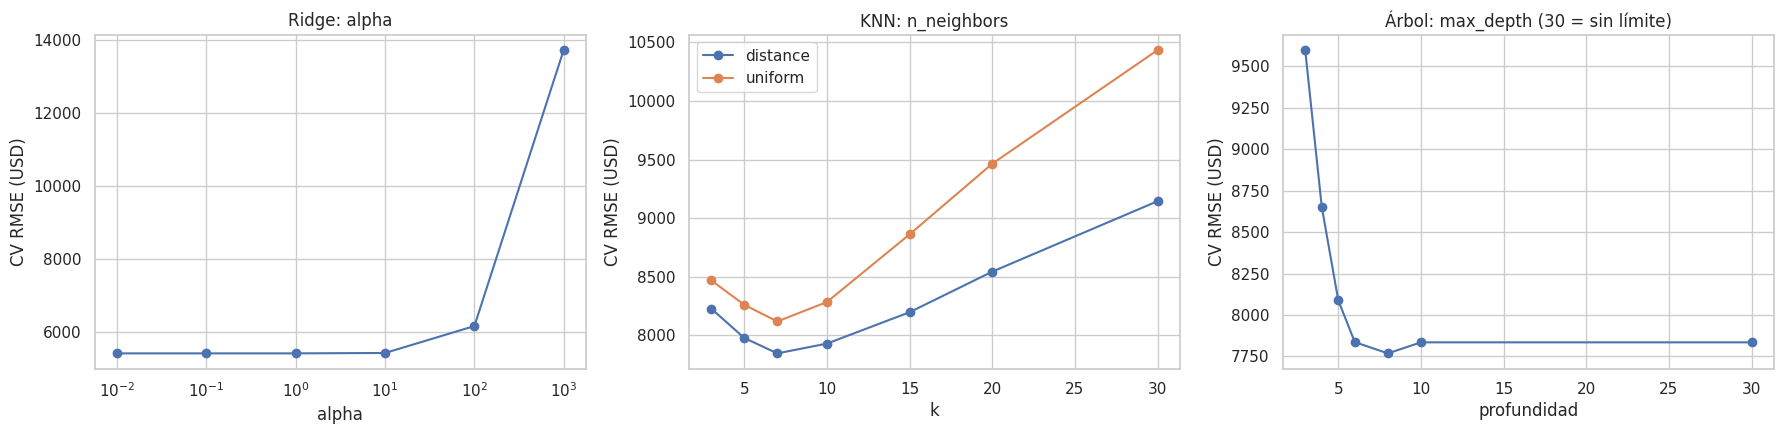

In [7]:
# Efecto de los hiperparámetros principales sobre el RMSE de validación
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
r = pd.DataFrame(busquedas['Ridge'].cv_results_); axes[0].semilogx(r['param_modelo__alpha'].astype(float), -r['mean_test_score'], 'o-')
axes[0].set(title='Ridge: alpha', xlabel='alpha', ylabel='CV RMSE (USD)')
k = pd.DataFrame(busquedas['KNN'].cv_results_)
for w, g in k.groupby('param_modelo__weights'):
    axes[1].plot(g.groupby('param_modelo__n_neighbors')['mean_test_score'].max().index,
                 -g.groupby('param_modelo__n_neighbors')['mean_test_score'].max().values, 'o-', label=w)
axes[1].set(title='KNN: n_neighbors', xlabel='k', ylabel='CV RMSE (USD)'); axes[1].legend()
a = pd.DataFrame(busquedas['Árbol de decisión'].cv_results_)
a['prof'] = a['param_max_depth'].fillna(30).astype(float)
g = a.groupby('prof')['mean_test_score'].max()
axes[2].plot(g.index, -g.values, 'o-'); axes[2].set(title='Árbol: max_depth (30 = sin límite)', xlabel='profundidad', ylabel='CV RMSE (USD)')
plt.tight_layout(); plt.savefig('figuras/fig8_hiperparametros.png', dpi=150); plt.show()

**Lectura de resultados (validación cruzada, RMSE en USD):**

| Modelo | Mejores hiperparámetros | CV RMSE |
|---|---|---|
| Ridge | `alpha = 0.01` | 5.412 |
| SVR | kernel lineal, `C = 100`, `epsilon = 0.01` | 5.421 |
| MLP | 1 capa de 64 neuronas, `tanh`, `alpha = 1`, `learning_rate_init = 0.01` | 5.454 |
| Árbol de decisión | `max_depth = 8`, `min_samples_split = 10` | 7.768 |
| KNN | `k = 7`, `weights = distance`, `p = 2` | 7.847 |

- **Los modelos que capturan una relación lineal ganan con claridad** (≈ USD 5.400 contra ≈ USD 7.800). Esto es coherente con el punto 3.6: `YearsExperience` y `JobLevel` se relacionan con el salario de forma casi lineal.
- Ridge, SVR y MLP quedan **estadísticamente empatados**: la diferencia entre ellos (≈ USD 40) es mucho menor que la desviación entre pliegues (≈ ± USD 280).
- El mejor `alpha` de Ridge (0.01) está en el borde inferior de la malla: casi no necesita regularización (equivale a mínimos cuadrados), porque solo hay 7 predictoras y ~700 registros.
- El **SVR eligió el kernel lineal** sobre el RBF, y el MLP prefirió una red pequeña con regularización fuerte (`alpha = 1`): ambos confirman que no hay estructura no lineal importante por capturar.
- KNN y el árbol rinden peor porque aproximan una relación suave con "escalones" o vecindarios y, además, dividen los pocos datos disponibles.

### 1.2.3 Ajuste de hiperparámetros de los modelos de ensamble

Se ajustan los **tres** ensambles (votación, bagging y boosting) con la misma validación cruzada sobre el 70 % de entrenamiento.

- **Votación:** se toman los **3 mejores modelos clásicos** (por CV RMSE) ya ajustados en 1.2.2, y se busca el mejor reparto de **pesos** entre ellos.
- **Bagging:** árbol de decisión como estimador base; se ajusta el número de árboles, el tamaño de cada muestra bootstrap, la fracción de variables y la profundidad del árbol.
- **Boosting:** `GradientBoostingRegressor`; se ajustan el número de árboles, la tasa de aprendizaje, la profundidad y el submuestreo (`subsample`).

In [8]:
# --- Votación: 3 mejores clásicos con sus hiperparámetros ya optimizados
top3 = tabla_clasicos.index[:3].tolist()
print('Modelos del ensamble de votación:', top3)
voting = VotingRegressor([(n, clone(busquedas[n].best_estimator_)) for n in top3])
malla_voting = {'weights': [None, (2, 1, 1), (1, 2, 1), (1, 1, 2), (3, 2, 1), (1, 2, 3), (3, 1, 1), (1, 3, 1), (1, 1, 3)]}

# --- Bagging con árbol como estimador base
bagging = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=SEED), random_state=SEED, n_jobs=1)
malla_bagging = {'n_estimators': [50, 100], 'max_samples': [0.7, 1.0], 'max_features': [0.6, 1.0],
                 'estimator__max_depth': [4, 6, 8, None], 'estimator__min_samples_leaf': [1, 5]}

# --- Boosting
boosting = GradientBoostingRegressor(random_state=SEED)
malla_boosting = {'n_estimators': [100, 200, 300], 'learning_rate': [0.02, 0.05, 0.1],
                  'max_depth': [2, 3, 4], 'subsample': [0.7, 1.0]}

ensambles = {'Votación': (voting, malla_voting), 'Bagging': (bagging, malla_bagging), 'Boosting (Gradient Boosting)': (boosting, malla_boosting)}
filas_ens = []
for nombre, (est, malla) in ensambles.items():
    busquedas[nombre], fila = ajustar(nombre, est, malla)
    filas_ens.append(fila)

Modelos del ensamble de votación: ['Ridge', 'SVR', 'MLP']


Votación           CV RMSE =     5,410 ± 284  | {'weights': (3, 1, 1)}


Bagging            CV RMSE =     6,466 ± 282  | {'max_depth': 8, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_samples': 0.7, 'n_estimators': 100}


Boosting (Gradient Boosting) CV RMSE =     5,717 ± 330  | {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.7}


In [9]:
tabla_ensambles = pd.DataFrame(filas_ens).set_index('Modelo').sort_values('CV RMSE')
tabla_ensambles

,CV RMSE,CV RMSE (desv.),Combinaciones,Tiempo (s),Mejores hiperparámetros
Modelo,,,,,
Votación,"5,410.170",284.425,9,54.229,"{'weights': (3, 1, 1)}"
Boosting (Gradient Boosting),"5,716.679",330.278,54,41.343,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."
Bagging,"6,465.859",281.711,64,41.973,"{'max_depth': 8, 'min_samples_leaf': 1, 'max_f..."


**Lectura de resultados (validación cruzada, RMSE en USD):**

| Ensamble | Mejores hiperparámetros | CV RMSE |
|---|---|---|
| Votación (Ridge + SVR + MLP) | pesos (3, 1, 1) | 5.410 |
| Boosting (Gradient Boosting) | 300 árboles, `learning_rate = 0.05`, `max_depth = 2`, `subsample = 0.7` | 5.717 |
| Bagging (árboles) | 100 árboles, `max_depth = 8`, `max_samples = 0.7` | 6.466 |

- **Votación** combina los tres mejores clásicos y asigna el mayor peso a Ridge; el resultado (5.410) es prácticamente igual al de Ridge solo: como los tres modelos cometen errores casi idénticos, promediarlos no reduce el error.
- **Boosting** prefirió árboles muy pequeños (`max_depth = 2`), una tasa de aprendizaje baja y `subsample = 0.7`: es decir, mucha regularización para no sobreajustar. Mejora al árbol individual (7.768 → 5.717), pero no supera a los modelos lineales.
- **Bagging** reduce la varianza del árbol (7.768 → 6.466), pero cada árbol sigue aproximando por tramos una relación lineal, por lo que queda atrás.
- Hay que tener presente que los ensambles de árboles son los que más ganan al regularizarse, pero su techo está limitado por la naturaleza casi lineal del problema.

## 1.3 Medida de calidad del modelo

### 1.3.1 Evaluación de los modelos con el set de pruebas

Cada modelo (con los mejores hiperparámetros, reentrenado con el 70 %) se evalúa **una sola vez** sobre el 30 % de prueba, que ningún modelo vio durante el ajuste. Se compara el RMSE de validación cruzada con el RMSE de prueba y con el de entrenamiento para detectar **sobreajuste**.

In [10]:
filas = []
for nombre, gs in busquedas.items():
    m_te = metricas(gs.best_estimator_, X_test, y_test)
    m_tr = metricas(gs.best_estimator_, X_train, y_train)
    filas.append({'Modelo': nombre,
                  'Tipo': 'Ensamble' if nombre in ensambles else 'Clásico',
                  'RMSE train': m_tr['RMSE'], 'RMSE CV': -gs.best_score_,
                  'RMSE test': m_te['RMSE'], 'MAE test': m_te['MAE'],
                  'R2 test': m_te['R2'], 'MAPE test (%)': m_te['MAPE (%)']})
resultados = pd.DataFrame(filas).set_index('Modelo').sort_values('RMSE test')
resultados['Brecha test-train'] = resultados['RMSE test'] - resultados['RMSE train']
resultados

,Tipo,RMSE train,RMSE CV,RMSE test,MAE test,R2 test,MAPE test (%),Brecha test-train
Modelo,,,,,,,,
Ridge,Clásico,"5,372.728","5,412.070","5,341.923","4,197.557",0.936,5.521,-30.805
SVR,Clásico,"5,384.952","5,421.255","5,403.709","4,243.387",0.935,5.562,18.757
Votación,Ensamble,"5,381.178","5,410.170","5,413.877","4,275.856",0.934,5.637,32.699
Boosting (Gradient Boosting),Ensamble,"4,897.120","5,716.679","5,588.806","4,365.598",0.930,5.728,691.686
MLP,Clásico,"5,566.387","5,454.480","5,762.832","4,626.204",0.926,6.181,196.445
Bagging,Ensamble,"3,877.799","6,465.859","6,374.807","5,035.079",0.909,6.588,"2,497.008"
KNN,Clásico,887.369,"7,847.280","7,568.387","5,865.040",0.872,7.632,"6,681.018"
Árbol de decisión,Clásico,"4,602.257","7,768.225","7,573.174","5,891.081",0.872,7.770,"2,970.917"


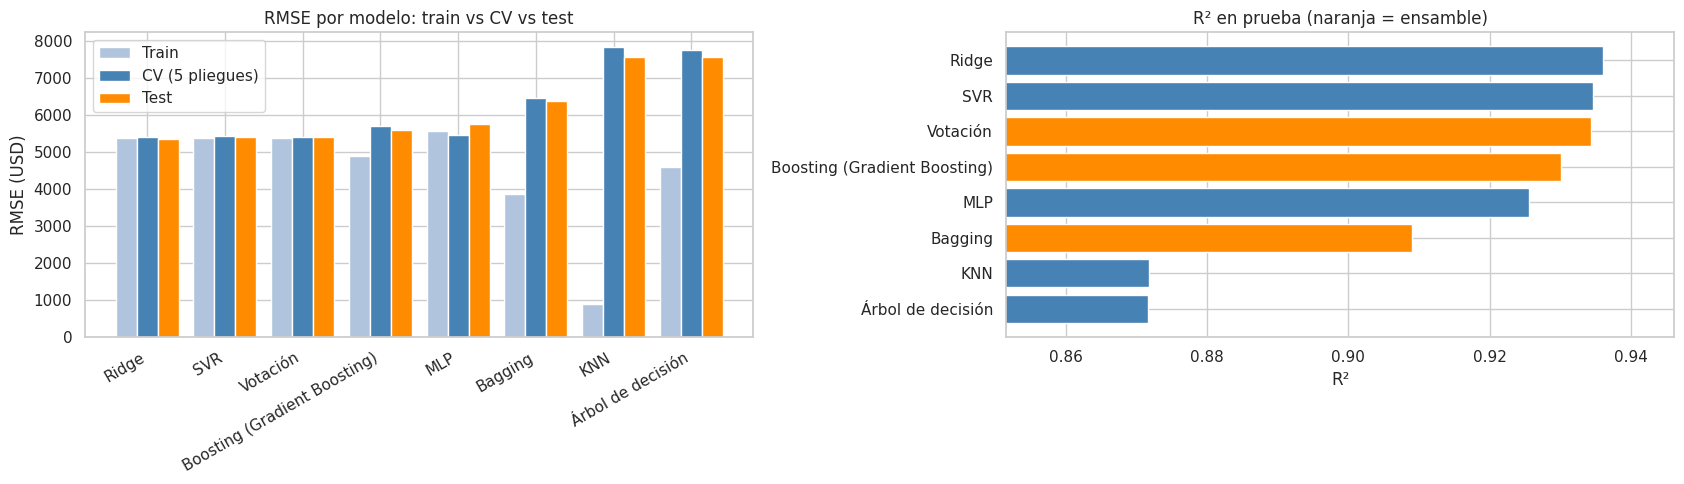

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(17, 5))
orden = resultados.index
x = np.arange(len(orden)); w = 0.27
ax[0].bar(x - w, resultados['RMSE train'], w, label='Train', color='lightsteelblue')
ax[0].bar(x, resultados['RMSE CV'], w, label='CV (5 pliegues)', color='steelblue')
ax[0].bar(x + w, resultados['RMSE test'], w, label='Test', color='darkorange')
ax[0].set_xticks(x); ax[0].set_xticklabels(orden, rotation=30, ha='right'); ax[0].set_ylabel('RMSE (USD)')
ax[0].set_title('RMSE por modelo: train vs CV vs test'); ax[0].legend()
colores = ['darkorange' if t == 'Ensamble' else 'steelblue' for t in resultados['Tipo']]
ax[1].barh(orden[::-1], resultados['R2 test'][::-1], color=colores[::-1])
ax[1].set_xlim(resultados['R2 test'].min() - 0.02, resultados['R2 test'].max() + 0.01)
ax[1].set_title('R² en prueba (naranja = ensamble)'); ax[1].set_xlabel('R²')
plt.tight_layout(); plt.savefig('figuras/fig9_comparacion_modelos.png', dpi=150); plt.show()

**Lectura de resultados (set de prueba, 299 registros):**

| Posición | Modelo | RMSE test | MAE test | R² test |
|---|---|---|---|---|
| 1 | Ridge | 5.342 | 4.198 | 0,936 |
| 2 | SVR | 5.404 | 4.243 | 0,935 |
| 3 | Votación | 5.414 | 4.276 | 0,934 |
| 4 | Boosting | 5.589 | 4.366 | 0,930 |
| 5 | MLP | 5.763 | 4.626 | 0,926 |
| 6 | Bagging | 6.375 | 5.035 | 0,909 |
| 7 | KNN | 7.568 | 5.865 | 0,872 |
| 8 | Árbol de decisión | 7.573 | 5.891 | 0,872 |

- **Ranking estable:** el orden en prueba coincide en lo esencial con el de validación cruzada, por lo que el ajuste con CV generalizó bien.
- **Sobreajuste:** Ridge, SVR y Votación tienen brecha train–test casi nula (< USD 35). En cambio KNN (RMSE de entrenamiento 887 contra 7.568 en prueba), el árbol (4.602 → 7.573) y Bagging (3.878 → 6.375) memorizan parte del entrenamiento.
- **Techo de error:** los mejores modelos se estancan en ≈ USD 5.400 de RMSE (R² ≈ 0,935); es probable que el resto sea ruido propio de los datos (variables no capturadas), no una limitación del algoritmo.
- **Los ensambles no superaron al mejor modelo simple:** votación y boosting quedaron cerca, pero no por encima de Ridge.

### 1.3.2 Selección del modelo con mejor desempeño

**Criterio:** menor RMSE en el set de prueba (misma métrica usada para el ajuste), verificando que (a) sea consistente con el RMSE de validación cruzada y (b) no tenga una brecha train–test preocupante. Si varios modelos quedan prácticamente empatados, se prefiere el más simple.

In [12]:
mejor_nombre = resultados.index[0]
modelo_final = busquedas[mejor_nombre].best_estimator_
print('MODELO SELECCIONADO:', mejor_nombre)
print('Hiperparámetros:', {k: v for k, v in busquedas[mejor_nombre].best_params_.items()})
print(resultados.loc[mejor_nombre, ['RMSE train', 'RMSE CV', 'RMSE test', 'MAE test', 'R2 test', 'MAPE test (%)']].round(3).to_string())
print()
print('Diferencia de RMSE test entre los 3 mejores:')
print(resultados['RMSE test'].head(3).round(0).to_string())

MODELO SELECCIONADO: Ridge
Hiperparámetros: {'modelo__alpha': 0.01}
RMSE train      5,372.728
RMSE CV         5,412.070
RMSE test       5,341.923
MAE test        4,197.557
R2 test             0.936
MAPE test (%)       5.521

Diferencia de RMSE test entre los 3 mejores:
Modelo
Ridge      5,342.000
SVR        5,404.000
Votación   5,414.000


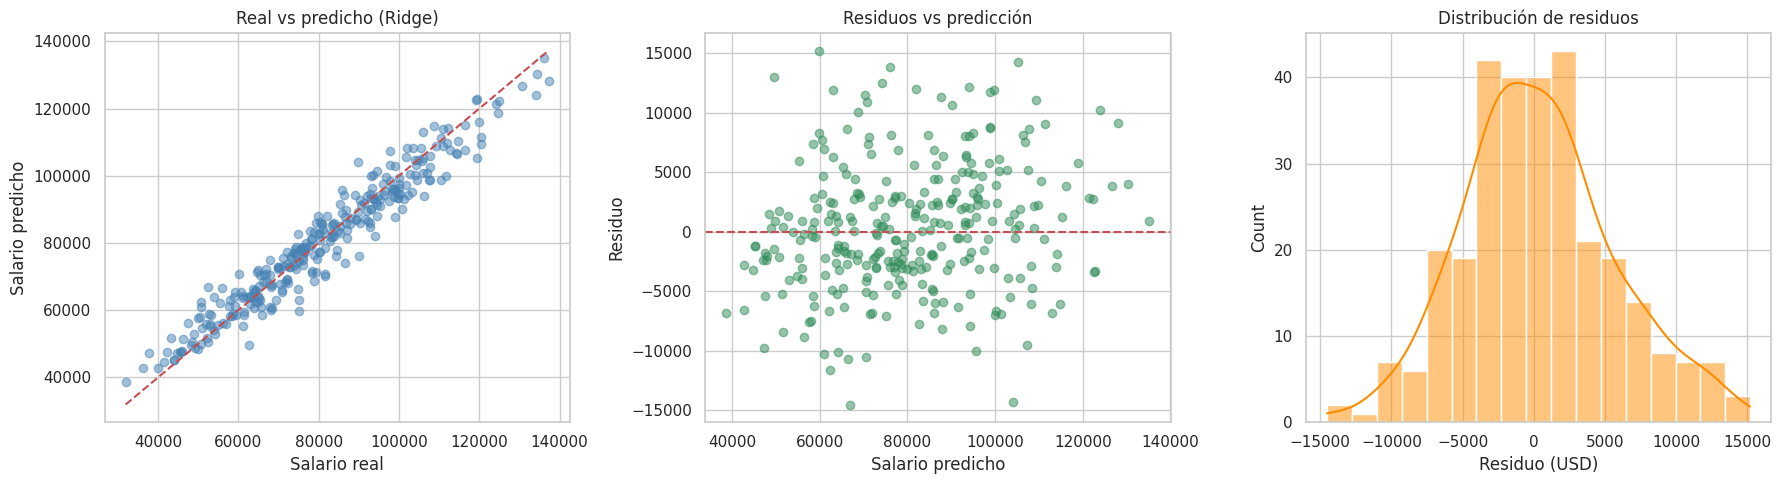

Sesgo medio de residuos: 336 | Residuos entre 5 % y 95 %: -7,627 a 10,277


In [13]:
pred = modelo_final.predict(X_test)
res = y_test.values - pred
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].scatter(y_test, pred, alpha=.5, color='steelblue')
lim = [y_test.min(), y_test.max()]; ax[0].plot(lim, lim, 'r--'); ax[0].set(xlabel='Salario real', ylabel='Salario predicho', title=f'Real vs predicho ({mejor_nombre})')
ax[1].scatter(pred, res, alpha=.5, color='seagreen'); ax[1].axhline(0, color='r', ls='--'); ax[1].set(xlabel='Salario predicho', ylabel='Residuo', title='Residuos vs predicción')
sns.histplot(res, kde=True, ax=ax[2], color='darkorange'); ax[2].set(xlabel='Residuo (USD)', title='Distribución de residuos')
plt.tight_layout(); plt.savefig('figuras/fig10_mejor_modelo.png', dpi=150); plt.show()
print(f'Sesgo medio de residuos: {res.mean():,.0f} | Residuos entre 5 % y 95 %: {np.percentile(res, 5):,.0f} a {np.percentile(res, 95):,.0f}')

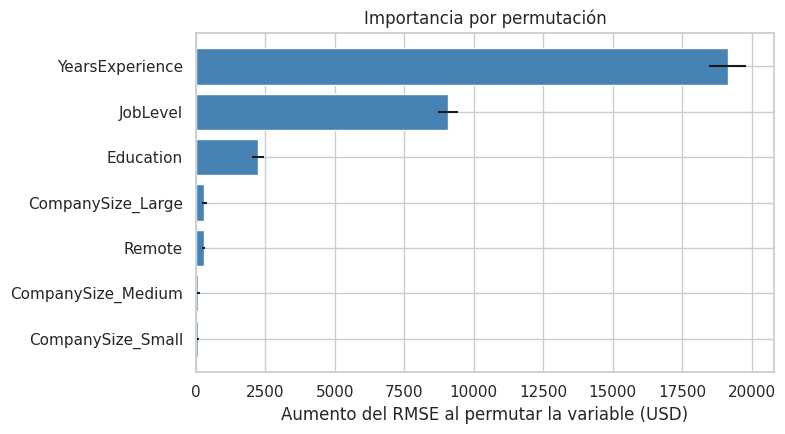

,Variable,Importancia (aumento RMSE USD),Desv.
0,YearsExperience,"19,152.296",666.875
1,JobLevel,"9,064.627",365.342
2,Education,"2,227.450",207.642
6,CompanySize_Large,294.504,87.986
3,Remote,275.173,62.533
5,CompanySize_Medium,82.820,45.328
4,CompanySize_Small,65.178,32.886


In [14]:
# Importancia de variables por permutación (sobre el set de prueba, métrica RMSE)
pi = permutation_importance(modelo_final, X_test, y_test, scoring='neg_root_mean_squared_error',
                            n_repeats=30, random_state=SEED, n_jobs=-1)
importancia = pd.DataFrame({'Variable': FEATURES, 'Importancia (aumento RMSE USD)': pi.importances_mean,
                            'Desv.': pi.importances_std}).sort_values('Importancia (aumento RMSE USD)', ascending=False)
plt.figure(figsize=(8, 4.5))
plt.barh(importancia['Variable'][::-1], importancia['Importancia (aumento RMSE USD)'][::-1], xerr=importancia['Desv.'][::-1], color='steelblue')
plt.title('Importancia por permutación'); plt.xlabel('Aumento del RMSE al permutar la variable (USD)')
plt.tight_layout(); plt.savefig('figuras/fig11_importancia.png', dpi=150); plt.show()
importancia

### Modelo seleccionado: **Ridge** (regresión lineal regularizada, `alpha = 0.01`)

**Justificación**
1. **Menor error en prueba** (RMSE USD 5.342; MAE USD 4.198; R² = 0,936; MAPE ≈ 5,5 %).
2. **Consistencia:** RMSE de entrenamiento (5.373), validación cruzada (5.412) y prueba (5.342) casi iguales: no hay sobreajuste.
3. **Parsimonia:** la diferencia con SVR (≈ USD 60) y con Votación (≈ USD 70) es muy inferior a la desviación entre pliegues (≈ USD 280), es decir, **estadísticamente están empatados**. Ante el empate se prefiere el modelo más simple, más rápido y más interpretable, que además es el que numéricamente quedó primero.
4. **Interpretabilidad y coherencia con el negocio:** cada coeficiente se puede explicar (años de experiencia, nivel del cargo, educación), lo cual es valioso para decisiones salariales y para justificar una predicción.

**Variables más influyentes (permutación en prueba):** `YearsExperience` (+USD 19.152 de RMSE si se desordena), `JobLevel` (+9.065) y `Education` (+2.227). `Remote` y el tamaño de la empresa aportan menos de USD 300 cada una, de acuerdo con el análisis del punto 3.6.

**Calidad del error:** el 90 % de los errores en prueba está entre –USD 7.627 y +USD 10.277 y el sesgo medio es bajo (≈ USD 336). La aplicación de Streamlit usa ese rango para mostrar un intervalo aproximado alrededor de cada predicción.

**Limitaciones:** con 994 registros y 7 variables, el modelo no captura efectos que no están en los datos (cargo específico, ciudad, industria); no debe extrapolarse fuera de 0–40 años de experiencia ni de los niveles 1–5.

## Exportación de modelos (`.joblib`) para la aplicación Streamlit

Se guardan:
- Un archivo `.joblib` por cada uno de los **8 modelos ajustados** (pipelines completos: escalado + modelo), para poder compararlos en la app.
- `modelo_final.joblib`: el modelo seleccionado.
- `metadata.joblib`: nombres de variables, métricas, importancias, rango de residuos y valores de referencia que usa la app.
- `test_predictions.csv`: set de prueba con la predicción de cada modelo.

In [15]:
def nombre_archivo(n):
    return (n.lower().replace(' (gradient boosting)', '').replace('ó', 'o').replace('á', 'a').replace('í', 'i')
            .replace(' de ', '_').replace(' ', '_'))

archivos = {}
for nombre, gs in busquedas.items():
    ruta = f'modelos/{nombre_archivo(nombre)}.joblib'
    joblib.dump(gs.best_estimator_, ruta, compress=3)
    archivos[nombre] = ruta
joblib.dump(modelo_final, 'modelos/modelo_final.joblib', compress=3)

# Predicciones de prueba para todos los modelos
test_pred = X_test.copy(); test_pred['Salary_real'] = y_test.values
for nombre, gs in busquedas.items():
    test_pred[f'pred_{nombre}'] = gs.best_estimator_.predict(X_test)
test_pred.to_csv('test_predictions.csv', index=False)

hiper = {n: {k.split('__')[-1]: (str(v) if not isinstance(v, (int, float, str, type(None))) else v)
             for k, v in gs.best_params_.items()} for n, gs in busquedas.items()}
metadata = {
    'features': FEATURES, 'target': TARGET,
    'modelo_final_nombre': mejor_nombre,
    'archivos_modelos': archivos,
    'resultados': resultados.reset_index(),
    'importancia': importancia.reset_index(drop=True),
    'hiperparametros': hiper,
    'residuo_p05': float(np.percentile(res, 5)), 'residuo_p95': float(np.percentile(res, 95)),
    'rmse_test_final': float(resultados.loc[mejor_nombre, 'RMSE test']),
    'education_map': {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
    'n_train': int(len(X_train)), 'n_test': int(len(X_test)),
    'rango_experiencia': (float(df['YearsExperience'].min()), float(df['YearsExperience'].max())),
}
joblib.dump(metadata, 'modelos/metadata.joblib', compress=3)
resultados.to_csv('resultados_modelos.csv')
print('Archivos generados:'); print(*sorted(os.listdir('modelos')), sep='\n')

Archivos generados:
arbol_decision.joblib
bagging.joblib
boosting.joblib
knn.joblib
metadata.joblib
mlp.joblib
modelo_final.joblib
ridge.joblib
svr.joblib
votacion.joblib


In [16]:
# Prueba de carga: el modelo exportado debe reproducir exactamente las predicciones
cargado = joblib.load('modelos/modelo_final.joblib')
assert np.allclose(cargado.predict(X_test), modelo_final.predict(X_test))
ejemplo = pd.DataFrame([{'YearsExperience': 10, 'JobLevel': 3, 'Education': 2, 'Remote': 1,
                         'CompanySize_Small': 0, 'CompanySize_Medium': 1, 'CompanySize_Large': 0}])
print(f"Ejemplo — 10 años, nivel 3, Master, remoto, empresa mediana → USD {cargado.predict(ejemplo)[0]:,.0f}")

Ejemplo — 10 años, nivel 3, Master, remoto, empresa mediana → USD 82,054


## Resumen del punto 4

| Paso | Resultado |
|---|---|
| 1.1 Selección | 5 clásicos (Ridge, KNN, Árbol, SVR, MLP) y 3 ensambles (Votación, Bagging, Boosting). |
| 1.2 Ajuste | `GridSearchCV` con CV estratificada de 5 pliegues sobre el 70 % (695 registros); métrica RMSE. |
| 1.3 Evaluación | 8 modelos evaluados sobre el 30 % (299 registros). |
| Mejor modelo | **Ridge**: RMSE = USD 5.342 · MAE = USD 4.198 · R² = 0,936. |
| Hallazgo clave | La relación es casi lineal; los modelos más complejos no mejoran y los basados en árboles/vecinos sobreajustan. |
| Entregables | 8 modelos `.joblib` + `modelo_final.joblib` + `metadata.joblib` + `app.py` (Streamlit). |